# 01 - Cleaning & Exploratory Data Analysis

Goal: turn the raw telemetry in `data/raw/data.csv` into a single
standardized `data/processed/cleaned_data.csv` that the rest of the project
uses, and document what the dataset actually looks like.

What this notebook does, in order:

1. Load the raw CSV and inspect schema, types, missingness.
2. Drop the columns flagged as irrelevant in phase 1 (engine-tuning /
   maintenance signals that don't reflect driver behavior) and any constant
   columns.
3. Inventory outliers (we do **not** remove them - in driving telemetry
   extreme values are often the safety events we care about).
4. Look at correlations and flag near-duplicate features.
5. Snake-case the column names, rename `Class` -> `driver_id`, and save.


In [1]:
import sys, os
from pathlib import Path

# Make the project root importable so that `import src` works no matter where
# Jupyter was launched from.
HERE = Path(os.getcwd()).resolve()
ROOT = HERE if (HERE / "src").is_dir() else HERE.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("project root:", ROOT)


project root: C:\Users\moham\Desktop\Projects\Driver_assessment_classification_model


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

RAW_PATH = ROOT / "data" / "raw" / "data.csv"
CLEAN_PATH = ROOT / "data" / "processed" / "cleaned_data.csv"


## 1. Load and inspect

In [3]:
df = pd.read_csv(RAW_PATH)
df.columns = df.columns.str.strip()
df = df.replace([np.inf, -np.inf], np.nan)
df["Class"] = df["Class"].astype(str).str.strip().str.upper()
df.loc[df["Class"].isin(["", "NAN", "NONE", "NULL"]), "Class"] = np.nan

print("shape:", df.shape)
print("dtypes (counts):")
print(df.dtypes.value_counts())
print("missing values total:", int(df.isna().sum().sum()))
df.head()


shape: (94380, 54)
dtypes (counts):
float64    27
int64      26
object      1
Name: count, dtype: int64
missing values total: 0


,Fuel_consumption,Accelerator_Pedal_value,Throttle_position_signal,Short_Term_Fuel_Trim_Bank1,Intake_air_pressure,Filtered_Accelerator_Pedal_value,Absolute_throttle_position,Engine_soacking_time,Inhibition_of_engine_fuel_cut_off,Engine_in_fuel_cut_off,Fuel_Pressure,Long_Term_Fuel_Trim_Bank1,Engine_speed,Engine_torque_after_correction,Torque_of_friction,Flywheel_torque_(after_torque_interventions),Current_spark_timing,Engine_coolant_temperature,Engine_Idel_Target_Speed,Engine_torque,Calculated_LOAD_value,Minimum_indicated_engine_torque,Maximum_indicated_engine_torque,Flywheel_torque,Torque_scaling_factor(standardization),Standard_Torque_Ratio,Requested_spark_retard_angle_from_TCU,TCU_requests_engine_torque_limit_(ETL),TCU_requested_engine_RPM_increase,Target_engine_speed_used_in_lock-up_module,Glow_plug_control_request,Activation_of_Air_compressor,Torque_converter_speed,Current_Gear,Engine_coolant_temperature.1,Wheel_velocity_front_left-hand,Wheel_velocity_rear_right-hand,Wheel_velocity_front_right-hand,Wheel_velocity_rear_left-hand,Torque_converter_turbine_speed_-_Unfiltered,Clutch_operation_acknowledge,Converter_clutch,Gear_Selection,Vehicle_speed,Acceleration_speed_-_Longitudinal,Indication_of_brake_switch_ON/OFF,Master_cylinder_pressure,Calculated_road_gradient,Acceleration_speed_-_Lateral,Steering_wheel_speed,Steering_wheel_angle,Time(s),Class,PathOrder
0,268.8,0.0,5.2,0.0,33,0,13.3,3,0,0,0,-0.8,929,5.5,9.0,-5.9,-8.6,95,650,5.5,23.9,2.0,58.2,-5.9,230,1,15,508,0.0,3040,0,0,939.3,0,87,0.0,0.0,0.0,0.0,935.5,1,0,0,0,-8.5,1,325.5,0.0,-8.8,0,-3.4,1,A,1
1,243.2,0.0,6.1,0.0,40,0,13.7,3,0,0,0,-0.8,726,7.0,7.8,1.7,-11.3,95,670,7.0,30.6,2.0,53.9,1.8,230,1,15,508,0.0,3040,0,0,710.0,0,87,0.0,0.0,0.0,0.0,709.5,1,0,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,2,A,1
2,217.6,0.0,5.2,0.0,41,0,13.7,3,0,0,0,-0.8,685,7.0,7.4,-3.0,-12.8,95,670,7.0,31.8,2.0,53.1,-2.8,230,1,15,508,0.0,3040,0,0,663.3,0,87,0.0,0.0,0.0,0.0,663.5,1,0,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,3,A,1
3,204.8,0.0,4.7,0.0,38,0,13.3,3,0,0,0,-0.8,675,7.0,6.6,-1.3,-9.8,95,670,7.0,29.0,2.0,53.1,-1.2,230,1,15,508,0.0,3040,0,0,652.5,0,87,0.0,0.0,0.0,0.0,653.0,1,0,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,4,A,1
4,217.6,0.0,5.7,0.0,40,0,13.7,3,0,0,0,-0.8,716,8.2,11.3,-15.6,-7.9,95,670,8.2,30.2,2.0,53.5,-15.9,230,1,15,508,0.0,3040,0,1,692.5,0,87,0.0,0.0,0.0,0.0,693.8,1,0,0,0,0.1,1,0.9,0.0,-0.2,0,-3.5,5,A,1


## 2. Drop irrelevant + constant columns

The phase-1 report flagged a set of engine-tuning / maintenance signals
that don't reflect *how* a person is driving (fuel trim, spark timing,
TCU torque requests, glow-plug control, etc.). We drop them here. We also
drop any column whose value never changes.


In [4]:
PHASE1_DROP = [
    "Short_Term_Fuel_Trim_Bank1",
    "Engine_soacking_time",
    "Inhibition_of_engine_fuel_cut_off",
    "Fuel_Pressure",
    "Long_Term_Fuel_Trim_Bank1",
    "Current_spark_timing",
    "Engine_coolant_temperature",
    "Engine_Idel_Target_Speed",
    "Minimum_indicated_engine_torque",
    "Maximum_indicated_engine_torque",
    "Torque_scaling_factor(standardization)",
    "Standard_Torque_Ratio",
    "Requested_spark_retard_angle_from_TCU",
    "TCU_requests_engine_torque_limit_(ETL)",
    "TCU_requested_engine_RPM_increase",
    "Target_engine_speed_used_in_lock-up_module",
    "Glow_plug_control_request",
    "Activation_of_Air_compressor",
    "Torque_converter_speed",
    "Torque_converter_turbine_speed_-_Unfiltered",
    "Converter_clutch",
    "Engine_coolant_temperature.1",
]
df = df.drop(columns=[c for c in PHASE1_DROP if c in df.columns])
print("after phase-1 drop:", df.shape)


after phase-1 drop: (94380, 32)


In [5]:
# Constant columns add no information.
nunique = df.nunique(dropna=False)
constant_cols = nunique[nunique <= 1].index.tolist()
print("constant columns:", constant_cols)
df = df.drop(columns=constant_cols)
print("after constant drop:", df.shape)


constant columns: ['Filtered_Accelerator_Pedal_value']
after constant drop: (94380, 31)


## 3. Class balance, duplicates, dtypes

Class
A     7240
B    12864
C     7500
D    13244
E     8436
F    11012
G     7492
H     9880
I     7808
J     8904
Name: count, dtype: int64
full-row duplicates: 0


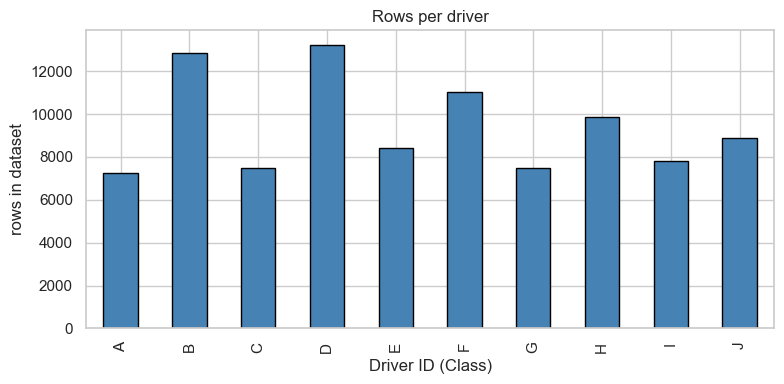

In [6]:
class_counts = df["Class"].value_counts().sort_index()
print(class_counts)
print("full-row duplicates:", int(df.duplicated().sum()))

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot.bar(ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("Driver ID (Class)")
ax.set_ylabel("rows in dataset")
ax.set_title("Rows per driver")
plt.tight_layout(); plt.show()


## 4. Outlier inventory (count, do not remove)

In driving telemetry, extreme values are usually *the* event of interest
(emergency brake, sharp turn). We just inventory them so we know which
sensors are heavy-tailed.


In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

def iqr_outlier_count(s: pd.Series) -> int:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum())

outlier_df = (
    pd.DataFrame({"feature": numeric_cols,
                  "outliers": [iqr_outlier_count(df[c]) for c in numeric_cols]})
      .assign(outlier_pct=lambda d: 100 * d["outliers"] / len(df))
      .sort_values("outlier_pct", ascending=False)
      .reset_index(drop=True)
)
outlier_df.head(15)


,feature,outliers,outlier_pct
0,Calculated_road_gradient,28728,30.438652
1,Accelerator_Pedal_value,23529,24.930070
2,Steering_wheel_angle,15637,16.568129
3,Master_cylinder_pressure,13757,14.576181
4,Acceleration_speed_-_Lateral,12336,13.070566
5,Steering_wheel_speed,9579,10.149396
6,Acceleration_speed_-_Longitudinal,8545,9.053825
7,Throttle_position_signal,7556,8.005933
8,Absolute_throttle_position,7393,7.833227
9,Engine_in_fuel_cut_off,6347,6.724942


### Boxplots of the sensors most relevant to driver behavior

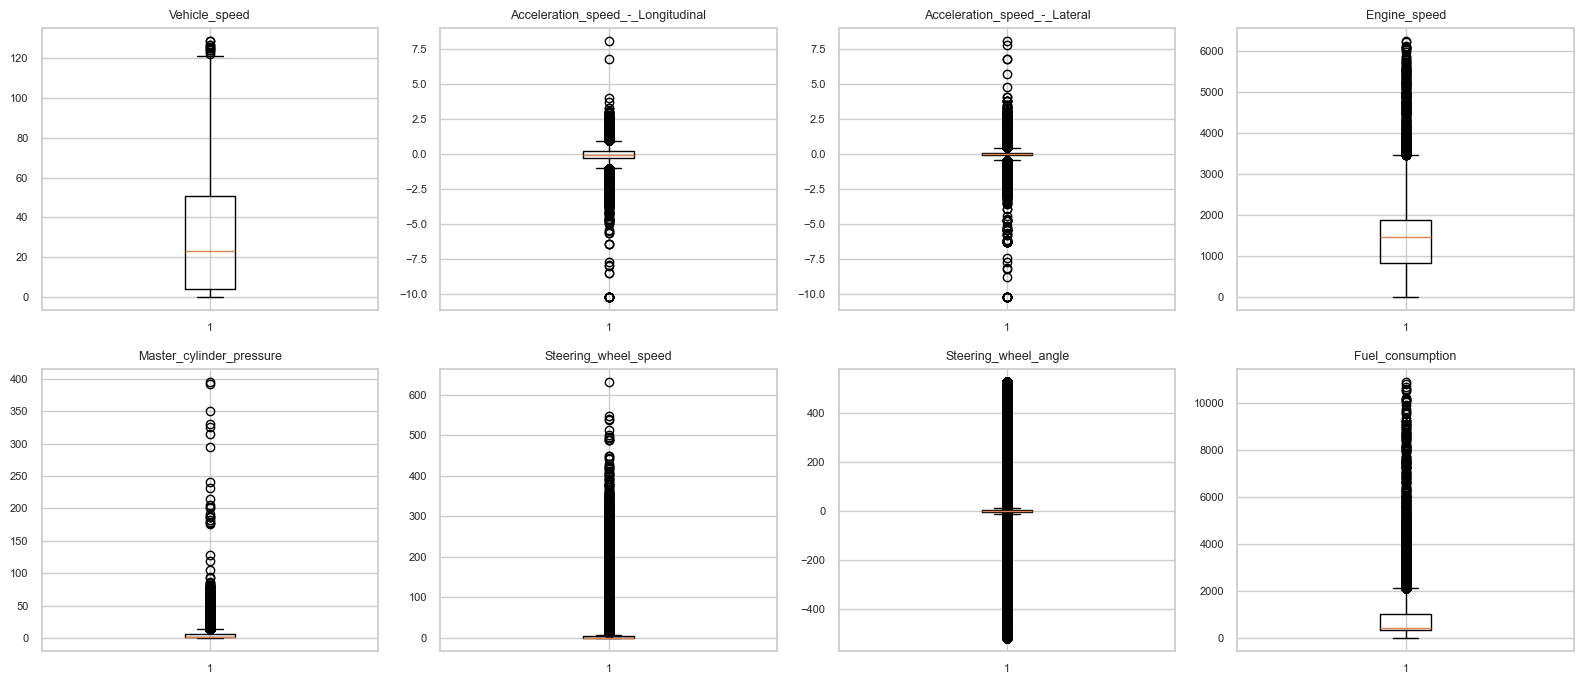

In [8]:
KEY_SENSORS = [
    "Vehicle_speed",
    "Acceleration_speed_-_Longitudinal",
    "Acceleration_speed_-_Lateral",
    "Engine_speed",
    "Master_cylinder_pressure",
    "Steering_wheel_speed",
    "Steering_wheel_angle",
    "Fuel_consumption",
]
KEY_SENSORS = [c for c in KEY_SENSORS if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, KEY_SENSORS):
    ax.boxplot(df[col].dropna(), vert=True, showfliers=True)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()


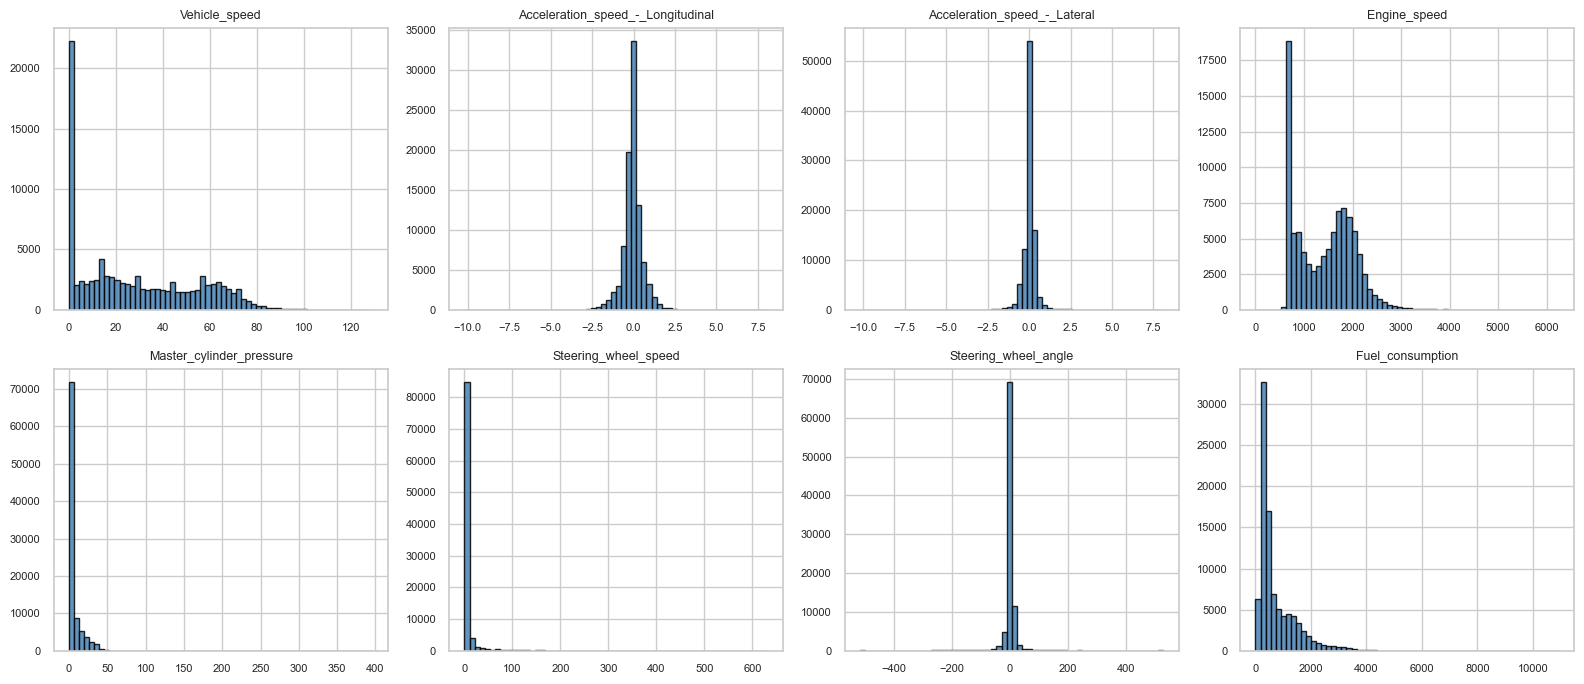

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, KEY_SENSORS):
    ax.hist(df[col].dropna(), bins=60, color="steelblue", edgecolor="black", alpha=0.85)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()


### A short slice of the telemetry for one driver

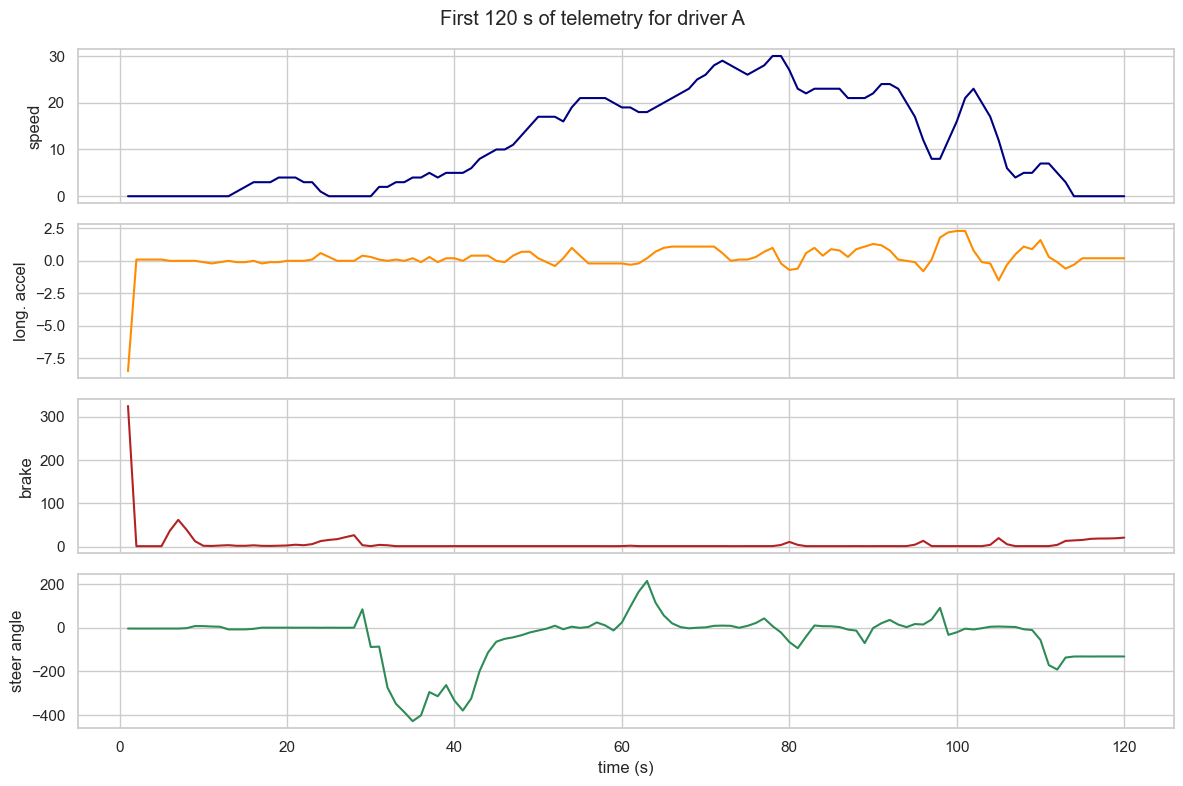

In [10]:
sample_driver = "A"
slice_df = df[df["Class"] == sample_driver].head(120)

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].plot(slice_df["Time(s)"], slice_df["Vehicle_speed"], color="navy")
axes[0].set_ylabel("speed")
axes[1].plot(slice_df["Time(s)"], slice_df["Acceleration_speed_-_Longitudinal"], color="darkorange")
axes[1].set_ylabel("long. accel")
axes[2].plot(slice_df["Time(s)"], slice_df["Master_cylinder_pressure"], color="firebrick")
axes[2].set_ylabel("brake")
axes[3].plot(slice_df["Time(s)"], slice_df["Steering_wheel_angle"], color="seagreen")
axes[3].set_ylabel("steer angle")
axes[3].set_xlabel("time (s)")
fig.suptitle(f"First 120 s of telemetry for driver {sample_driver}")
plt.tight_layout(); plt.show()


## 5. Correlation structure

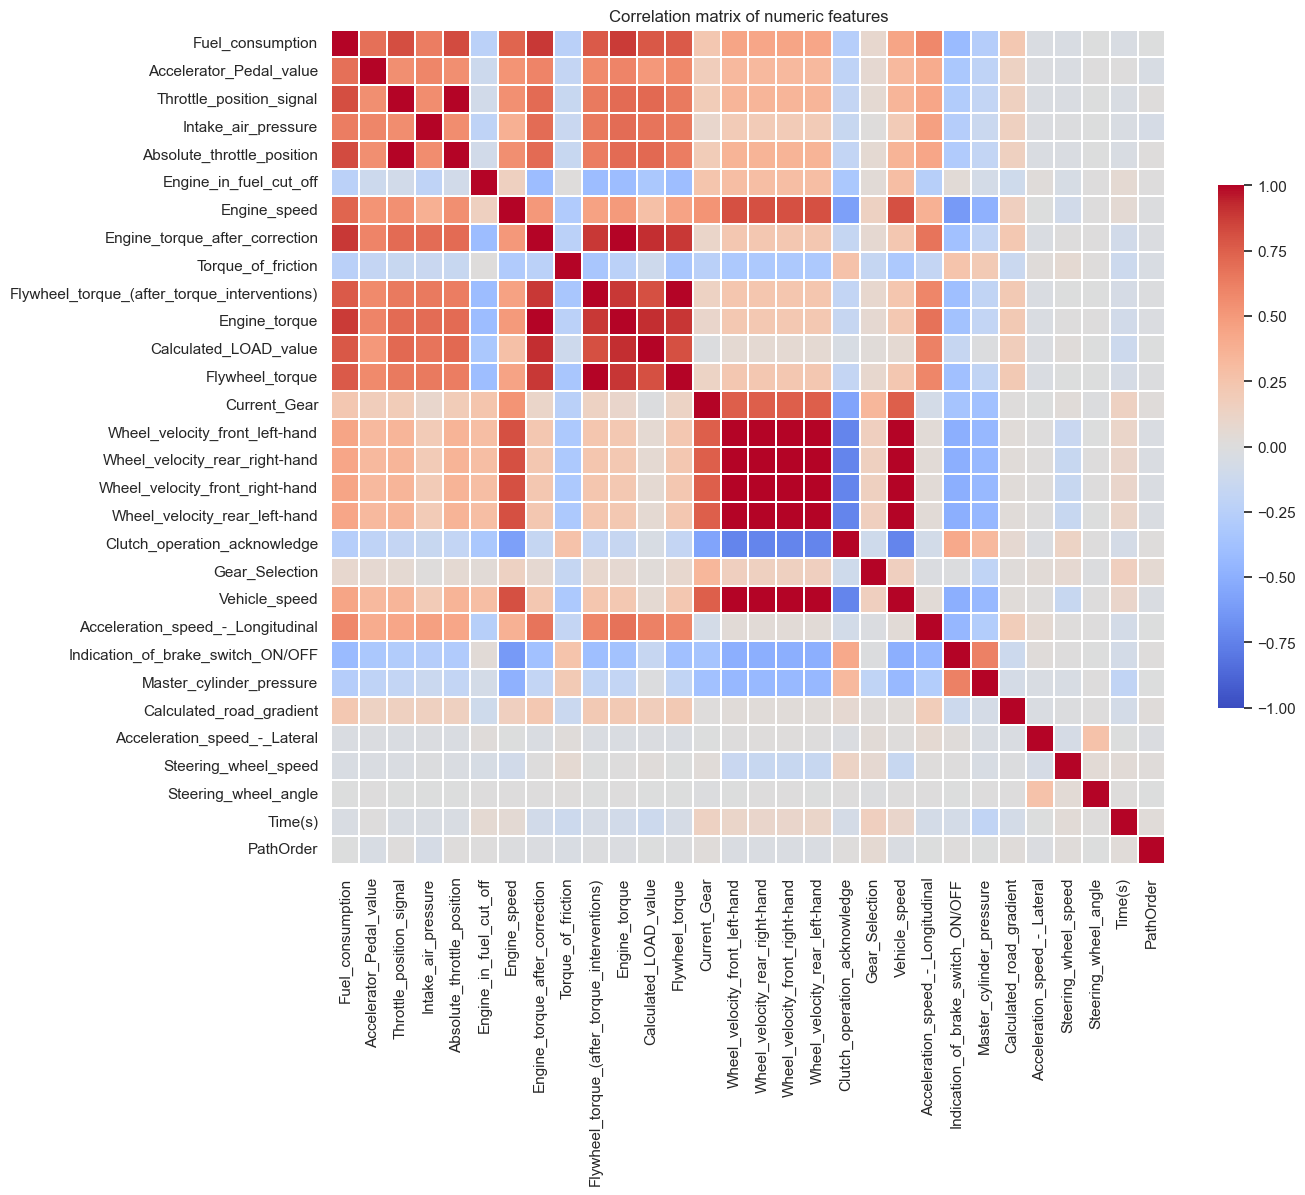

In [11]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.6},
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title("Correlation matrix of numeric features")
plt.tight_layout(); plt.show()


In [12]:
pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c = corr.iloc[i, j]
        if abs(c) > 0.9:
            pairs.append((cols[i], cols[j], round(c, 3)))
high_corr = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "corr"]).sort_values("corr", ascending=False)
print(f"{len(high_corr)} pairs with |corr| > 0.9")
high_corr


15 pairs with |corr| > 0.9


,feature_1,feature_2,corr
6,Wheel_velocity_front_left-hand,Wheel_velocity_front_right-hand,1.000
5,Wheel_velocity_front_left-hand,Wheel_velocity_rear_right-hand,1.000
11,Wheel_velocity_rear_right-hand,Vehicle_speed,1.000
10,Wheel_velocity_rear_right-hand,Wheel_velocity_rear_left-hand,1.000
9,Wheel_velocity_rear_right-hand,Wheel_velocity_front_right-hand,1.000
8,Wheel_velocity_front_left-hand,Vehicle_speed,1.000
7,Wheel_velocity_front_left-hand,Wheel_velocity_rear_left-hand,1.000
13,Wheel_velocity_front_right-hand,Vehicle_speed,1.000
12,Wheel_velocity_front_right-hand,Wheel_velocity_rear_left-hand,1.000
14,Wheel_velocity_rear_left-hand,Vehicle_speed,1.000


The four wheel velocities + `Vehicle_speed` are essentially the
same signal, and `Engine_torque*`, `Flywheel_torque*`, `Throttle_position_signal`
vs `Absolute_throttle_position` are near-duplicates too. We keep all of
them in the cleaned export (some downstream notebooks may need them) but
the modelling notebooks select a non-redundant subset.


## 6. Standardize column names and export

In [13]:
import re

def to_snake(name: str) -> str:
    name = re.sub(r"[^0-9a-zA-Z]+", "_", str(name).strip())
    name = re.sub(r"_+", "_", name).strip("_").lower()
    return name

clean = df.copy()
clean.columns = [to_snake(c) for c in clean.columns]
clean = clean.rename(columns={"class": "driver_id"})

CLEAN_PATH.parent.mkdir(parents=True, exist_ok=True)
clean.to_csv(CLEAN_PATH, index=False)
print("saved:", CLEAN_PATH.relative_to(ROOT))
print("final shape:", clean.shape)
clean.head()


saved: data\processed\cleaned_data.csv
final shape: (94380, 31)


,fuel_consumption,accelerator_pedal_value,throttle_position_signal,intake_air_pressure,absolute_throttle_position,engine_in_fuel_cut_off,engine_speed,engine_torque_after_correction,torque_of_friction,flywheel_torque_after_torque_interventions,engine_torque,calculated_load_value,flywheel_torque,current_gear,wheel_velocity_front_left_hand,wheel_velocity_rear_right_hand,wheel_velocity_front_right_hand,wheel_velocity_rear_left_hand,clutch_operation_acknowledge,gear_selection,vehicle_speed,acceleration_speed_longitudinal,indication_of_brake_switch_on_off,master_cylinder_pressure,calculated_road_gradient,acceleration_speed_lateral,steering_wheel_speed,steering_wheel_angle,time_s,driver_id,pathorder
0,268.8,0.0,5.2,33,13.3,0,929,5.5,9.0,-5.9,5.5,23.9,-5.9,0,0.0,0.0,0.0,0.0,1,0,0,-8.5,1,325.5,0.0,-8.8,0,-3.4,1,A,1
1,243.2,0.0,6.1,40,13.7,0,726,7.0,7.8,1.7,7.0,30.6,1.8,0,0.0,0.0,0.0,0.0,1,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,2,A,1
2,217.6,0.0,5.2,41,13.7,0,685,7.0,7.4,-3.0,7.0,31.8,-2.8,0,0.0,0.0,0.0,0.0,1,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,3,A,1
3,204.8,0.0,4.7,38,13.3,0,675,7.0,6.6,-1.3,7.0,29.0,-1.2,0,0.0,0.0,0.0,0.0,1,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,4,A,1
4,217.6,0.0,5.7,40,13.7,0,716,8.2,11.3,-15.6,8.2,30.2,-15.9,0,0.0,0.0,0.0,0.0,1,0,0,0.1,1,0.9,0.0,-0.2,0,-3.5,5,A,1
